# 06. Classifiers on dataset B

Trains simple classifiers (TF-IDF + SVM, LogReg, MLP, RandomForest) to pick the tool from the
prompt, and compares them with the local LLM (Llama 3.2 3B) on dataset B.

Every prediction here is **out-of-fold**: each row is predicted by a model that never saw it
during training. Two ways of splitting the data are used, because they answer different questions:

1. **Random 5-fold** (stratified on tool and difficulty). This is how dataset A was evaluated.
   Rows built from the same template can land in both training and test.
2. **Template-held-out 5-fold** (`GroupKFold` on the `family` column). All rows from one template
   stay together, so the test set contains phrasings the model has not seen in training.

The notebook adds two columns to `cyber_dataset_B.csv`: `pred_svm` (protocol 2) and
`pred_svm_random_cv` (protocol 1).

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GroupKFold, GroupShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix

B = pd.read_csv("cyber_dataset_B.csv")
B = B.drop(columns=[c for c in ["pred_svm", "pred_svm_random_cv"] if c in B.columns])
X = B["prompt"].astype(str)
y = B["tool_ground_truth"].to_numpy()
is_new = (B["dataset"] == "B").to_numpy()
is_A = ~is_new
print(len(B), "rows |", is_A.sum(), "from dataset A,", is_new.sum(), "new")

MODELS = {
    "SVM":          SVC(kernel="linear", random_state=42),
    "LogReg":       LogisticRegression(max_iter=1000, random_state=42),
    "MLP":          MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
}

1500 rows | 640 from dataset A, 860 new


## 1. Out-of-fold predictions under both protocols

The assertion checks that no row is ever in the training part of the fold that predicts it, and
that every row is predicted exactly once.

In [2]:
strata = (B["tool_ground_truth"] + "_" + B["difficulty"]).to_numpy()
groups = B["family"].to_numpy()

def out_of_fold(splits):
    oof = {m: np.empty(len(B), dtype=object) for m in MODELS}
    times_predicted = np.zeros(len(B), dtype=int)
    for tr, te in splits:
        assert not (set(tr) & set(te)), "a row is in both train and test"
        vec = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)   # fit on train only
        Xtr, Xte = vec.fit_transform(X.iloc[tr]), vec.transform(X.iloc[te])
        for name, proto in MODELS.items():
            oof[name][te] = clone(proto).fit(Xtr, y[tr]).predict(Xte)
        times_predicted[te] += 1
    assert (times_predicted == 1).all(), "every row must be predicted exactly once"
    return oof

random_splits = list(StratifiedKFold(5, shuffle=True, random_state=42).split(X, strata))
group_splits  = list(GroupKFold(5).split(X, y, groups))

oof_random = out_of_fold(random_splits)
oof_group  = out_of_fold(group_splits)
print("OK: all predictions are out-of-fold, each row predicted once, for both protocols")

OK: all predictions are out-of-fold, each row predicted once, for both protocols


## 2. Accuracy: Llama vs the classifiers

Columns: all of dataset B (1500), the original dataset A rows (640), and the new rows (860).

In [3]:
def acc(pred, mask=None):
    ok = np.asarray(pred, dtype=object) == y
    return ok.mean() if mask is None else ok[mask].mean()

llama = B["tool_predicted"].to_numpy()
rows = [{"method": "Llama 3.2 3B (local LLM)", "protocol": "none",
         "all B": acc(llama), "A rows": acc(llama, is_A), "new rows": acc(llama, is_new),
         "macro F1": f1_score(y, llama, average="macro")}]
for label, oof in [("random 5-fold", oof_random), ("template-held-out", oof_group)]:
    for name in MODELS:
        p = oof[name]
        rows.append({"method": name, "protocol": label, "all B": acc(p),
                     "A rows": acc(p, is_A), "new rows": acc(p, is_new),
                     "macro F1": f1_score(y, p, average="macro")})
results = pd.DataFrame(rows)
show = results.copy()
for c in ["all B", "A rows", "new rows"]:
    show[c] = (show[c] * 100).round(1).astype(str) + "%"
show["macro F1"] = show["macro F1"].round(3)
show

,method,protocol,all B,A rows,new rows,macro F1
0,Llama 3.2 3B (local LLM),none,77.5%,79.4%,76.0%,0.687
1,SVM,random 5-fold,98.1%,98.9%,97.6%,0.981
2,LogReg,random 5-fold,97.4%,98.9%,96.3%,0.974
3,MLP,random 5-fold,98.1%,98.9%,97.6%,0.981
4,RandomForest,random 5-fold,95.5%,97.3%,94.2%,0.955
5,SVM,template-held-out,84.7%,95.5%,76.7%,0.848
6,LogReg,template-held-out,82.5%,91.6%,75.7%,0.825
7,MLP,template-held-out,83.7%,95.0%,75.2%,0.838
8,RandomForest,template-held-out,77.4%,88.8%,69.0%,0.773


## 3. Trained only on dataset A, tested on the new rows

How well do classifiers trained on the original 640 queries handle the new, harder ones?

In [4]:
vec = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
XA = vec.fit_transform(X[is_A]); XN = vec.transform(X[is_new])
a_to_new = {name: (clone(proto).fit(XA, y[is_A]).predict(XN) == y[is_new]).mean()
            for name, proto in MODELS.items()}
llama_new = (llama[is_new] == y[is_new]).mean()
print(f"Llama 3.2 on the new rows: {llama_new:.1%}")
for name, v in a_to_new.items():
    print(f"{name:13} trained on A, tested on new rows: {v:.1%}")

Llama 3.2 on the new rows: 76.0%
SVM           trained on A, tested on new rows: 68.7%
LogReg        trained on A, tested on new rows: 67.1%
MLP           trained on A, tested on new rows: 68.8%
RandomForest  trained on A, tested on new rows: 58.3%


## 4. Accuracy by category (new rows)

In [5]:
new = B[is_new].copy()
new["Llama"] = llama[is_new] == y[is_new]
new["SVM, random folds"] = oof_random["SVM"][is_new] == y[is_new]
new["SVM, template-held-out"] = oof_group["SVM"][is_new] == y[is_new]
cat = new.groupby("category")[["Llama", "SVM, random folds", "SVM, template-held-out"]].mean()
cat.insert(0, "n", new.groupby("category").size())
cat.loc[:, cat.columns[1:]] = (cat[cat.columns[1:]] * 100).round(1)
cat

,n,Llama,"SVM, random folds","SVM, template-held-out"
category,,,,
cross_role,76,73.7,97.4,90.8
messy,176,76.7,94.9,66.5
near_miss,173,71.1,97.7,78.0
no_cue,171,73.1,99.4,71.9
shared_vocab,177,80.8,98.9,82.5
vocab_shift,87,82.8,96.6,80.5


## 5. Learning curve (template-held-out)

Accuracy of the SVM as the amount of training data grows. Test templates are always held out;
the training rows are subsampled.

In [6]:
fracs = [0.05, 0.1, 0.25, 0.5, 1.0]
curve = {f: [] for f in fracs}
for seed in range(5):
    tr_all, te = next(GroupShuffleSplit(1, test_size=0.2, random_state=seed).split(X, y, groups))
    rs = np.random.RandomState(seed)
    for f in fracs:
        tr = rs.choice(tr_all, size=max(20, int(len(tr_all) * f)), replace=False)
        v = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
        m = SVC(kernel="linear", random_state=42).fit(v.fit_transform(X.iloc[tr]), y[tr])
        curve[f].append((m.predict(v.transform(X.iloc[te])) == y[te]).mean())
for f in fracs:
    print(f"  {f:>4.0%} of training data ({int(len(tr_all) * f):4d} rows): {np.mean(curve[f]):.1%}")

    5% of training data (  61 rows): 43.3%
   10% of training data ( 122 rows): 60.4%
   25% of training data ( 307 rows): 74.7%
   50% of training data ( 614 rows): 81.1%
  100% of training data (1228 rows): 84.3%


## 6. Confusion matrix (SVM, template-held-out)

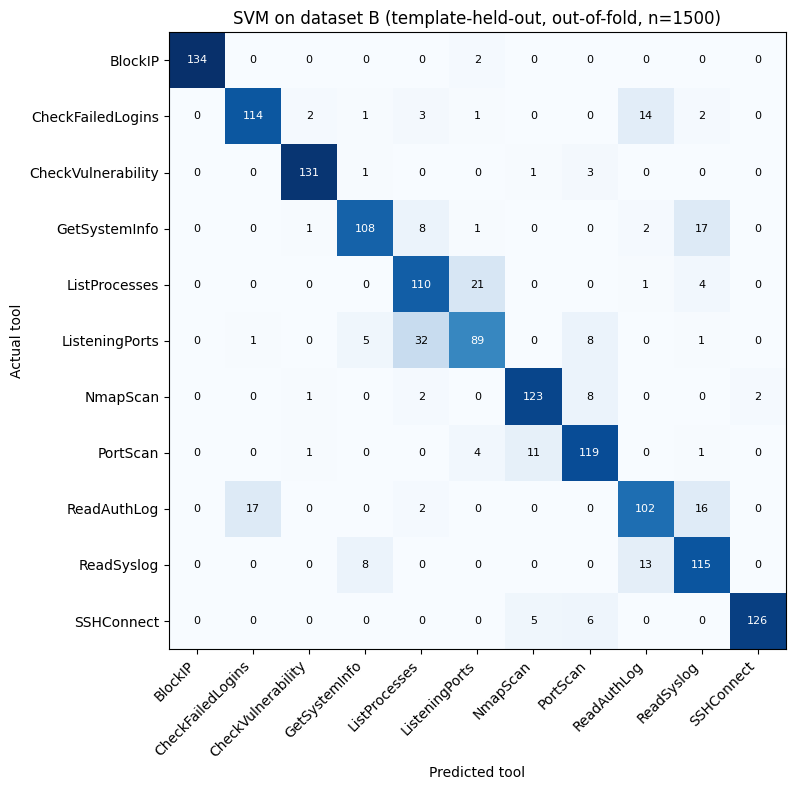

In [7]:
labels = sorted(set(y))
cm = confusion_matrix(y, oof_group["SVM"], labels=labels)
fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xlabel("Predicted tool"); ax.set_ylabel("Actual tool")
ax.set_title("SVM on dataset B (template-held-out, out-of-fold, n=1500)")
plt.tight_layout(); plt.savefig("confusion_matrix_B.png", dpi=150); plt.show()

## 7. Regression check against dataset A

Dataset A was evaluated earlier with random 5-fold on its 640 rows. Running the same protocol
on just those rows should reproduce those numbers.

In [8]:
A = B[is_A].reset_index(drop=True)
XA_, yA = A["prompt"].astype(str), A["tool_ground_truth"].to_numpy()
sA = (A["tool_ground_truth"] + "_" + A["difficulty"]).to_numpy()
hardA = (A["difficulty"] == "hard").to_numpy()
pA = np.empty(len(A), dtype=object)
for tr, te in StratifiedKFold(5, shuffle=True, random_state=42).split(XA_, sA):
    v = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
    pA[te] = SVC(kernel="linear", random_state=42).fit(v.fit_transform(XA_.iloc[tr]), yA[tr]).predict(v.transform(XA_.iloc[te]))
svm_a, svm_a_hard = (pA == yA).mean(), (pA[hardA] == yA[hardA]).mean()
llama_a = (A["tool_predicted"] == A["tool_ground_truth"]).mean()
print(f"dataset A, SVM random 5-fold: {svm_a:.1%} overall, {svm_a_hard:.1%} hard   (earlier: 98.3% / 94.5%)")
print(f"dataset A, Llama 3.2:         {llama_a:.1%}                          (earlier: 79.4%)")
assert abs(svm_a - 0.983) < 0.002 and abs(llama_a - 0.794) < 0.002

dataset A, SVM random 5-fold: 98.3% overall, 94.5% hard   (earlier: 98.3% / 94.5%)
dataset A, Llama 3.2:         79.4%                          (earlier: 79.4%)


## 8. Add the classifier columns and save

In [9]:
B["pred_svm"] = oof_group["SVM"]                 # template-held-out folds
B["pred_svm_random_cv"] = oof_random["SVM"]      # random folds
cols = ["prompt", "tool_ground_truth", "tool_predicted", "pred_svm", "pred_svm_random_cv",
        "agent_role", "difficulty", "category", "dataset", "family"]
B[cols].to_csv("cyber_dataset_B.csv", index=False)
results.to_csv("dataset_b_results.csv", index=False)
print("saved cyber_dataset_B.csv and dataset_b_results.csv")
print()
print("share of rows where the prediction disagrees with the annotated tool:")
print(f"  Llama                         : {(B.tool_predicted != B.tool_ground_truth).mean():.1%}")
print(f"  SVM, template-held-out folds  : {(B.pred_svm != B.tool_ground_truth).mean():.1%}")
print(f"  SVM, random folds             : {(B.pred_svm_random_cv != B.tool_ground_truth).mean():.1%}")

saved cyber_dataset_B.csv and dataset_b_results.csv

share of rows where the prediction disagrees with the annotated tool:
  Llama                         : 22.5%
  SVM, template-held-out folds  : 15.3%
  SVM, random folds             : 1.9%


## What to take from this

The numbers above are printed by the code, so they stay in sync with the data. In short:

- Under **random folds** the classifiers score very high on both A and the new rows, because rows
  from the same template appear in training and test.
- Under **template-held-out folds** the score drops, and the new rows are clearly harder than the
  original ones. This protocol is the better estimate of how the classifier handles phrasing it
  has not seen.
- On the new rows with templates held out, compare the SVM with Llama in section 2: the
  classifier's advantage over the local LLM is large only when sibling templates are in training.
- `pred_svm` (template-held-out) has far more disagreements with the annotated tool than
  `pred_svm_random_cv`, which is why it is the better input for an agreement/disagreement model.